# 20 - Word2Vec + RNN with Attention (Bahdanau-style)

Goal: Añadir atención al modelo del notebook 18 para que el output use TODOS los estados ocultos (no solo el último), ponderados por su relevancia.

**Problema en 18/19:** La RNN vanilla comprime toda la secuencia en un único vector `h_T`. Si el contexto es largo, la información de los primeros pasos se pierde (vanishing gradient).

**Solución con Attention:** El decoder (la capa de salida) "mira" todos los estados `h_1..h_T` y decide cuáles son más relevantes para predecir la siguiente palabra.

Run with: conda activate tfenv

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779734701.586348    8571 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779734701.734416    8571 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779734706.992160    8571 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.21.0


In [2]:
# Cargar embeddings Word2Vec preentrenados
class Word2VecLoader:
    def __init__(self, path='../myWord2Vec/v2/'):
        target_embeddings = np.load(path + 'target_embeddings.npy')
        context_embeddings = np.load(path + 'context_embeddings.npy')
        text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()

        self.target_embeddings = target_embeddings
        self.context_embeddings = context_embeddings
        self.final_embeddings = (target_embeddings + context_embeddings) / 2
        self.text_vocab = text_vocab
        self.idx_to_word = {idx: word for word, idx in text_vocab.items()}
        self.embedding_dim = target_embeddings.shape[1]

        self.embedding_layer = layers.Embedding(
            input_dim=target_embeddings.shape[0],
            output_dim=target_embeddings.shape[1],
            weights=[target_embeddings],
            trainable=False,
            name='pretrained_embedding'
        )

        print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape)
        print('Vocabulario cargado:', len(text_vocab))

    def encode(self, words):
        return [self.text_vocab[w] for w in words if w in self.text_vocab]

    def decode(self, token_id):
        return self.idx_to_word.get(int(token_id), '<unk>')

loader = Word2VecLoader()

E0000 00:00:1779734714.421554    8571 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779734714.450661    8571 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Embeddings cargados: (3291, 64) (3291, 64)
Vocabulario cargado: 3291


In [3]:
# Preparar datos de texto y crear secuencias contexto -> siguiente palabra
# Usamos window=5 (igual que notebook 18) para comparación justa
print('Loading gaianet/london dataset...')
ds = load_dataset('gaianet/london', split='train')
texts = [row['text'] if 'text' in row else row.get('content', '') for row in ds][:50000]
full_text = ' '.join(texts[:50000])

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]\"\'-0123456789') for w in words]
words = [w for w in words if len(w) > 2 and w in loader.text_vocab]
print(f'Total words used: {len(words)}')
print(f'Sample: {words[:20]}')

def create_sequences(words, window=5):
    X, y = [], []
    for i in range(len(words) - window):
        context = words[i:i + window]
        target = words[i + window]
        if all(w in loader.text_vocab for w in context + [target]):
            X.append([loader.text_vocab[w] for w in context])
            y.append(loader.text_vocab[target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X, y = create_sequences(words, window=5)
print(f'Sequences created: {len(X)}')
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

if len(X) == 0:
    raise ValueError('No se pudieron crear secuencias con el vocabulario cargado.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Loading gaianet/london dataset...
Total words used: 23651
Sample: ['london', 'the', 'capital', 'and', 'largest', 'city', 'england', 'and', 'the', 'united', 'kingdom', 'with', 'population', 'around', 'million', 'and', 'the', 'largest', 'city', 'western']
Sequences created: 23646
Input shape: (23646, 5), Target shape: (23646,)


In [ ]:
# RNN con Attention (Bahdanau-style)
# Diferencias con Notebook 18:
#   1. Colectamos TODOS los estados ocultos h_i (no solo el último)
#   2. Computamos pesos de atención alpha_i = softmax(score(h_i, h_T))
#   3. Context vector c = sum(alpha_i * h_i)
#   4. Output usa [c; h_T] concatenado (más información que solo h_T)

class AttentionRNNWordPredictor(keras.Model):
    def __init__(self, embedding_layer, vocab_size, embed_dim, hidden_dim=128):
        super().__init__()
        self.embedding = embedding_layer
        self.hidden_dim = hidden_dim
        # RNN weights
        self.Wx = layers.Dense(hidden_dim, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001))
        self.Wh = layers.Dense(hidden_dim, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001))
        self.b = self.add_weight(shape=(hidden_dim,), initializer='zeros', trainable=True, name='bias')
        # Attention weights
        self.W_att = layers.Dense(hidden_dim, use_bias=False, name='attention_projection')
        self.v_att = self.add_weight(shape=(hidden_dim,), initializer='glorot_uniform', trainable=True, name='attention_vector')
        # Output: ahora recibe context (hidden_dim) + final_h (hidden_dim) = 2*hidden_dim
        self.out = layers.Dense(vocab_size, activation='softmax')

    def call(self, inputs):
        x = self.embedding(inputs)                     # (batch, seq=5, embed_dim=64)
        x = tf.nn.dropout(x, rate=0.1)
        batch_size = tf.shape(x)[0]
        h = tf.zeros((batch_size, self.hidden_dim))

        # Paso 1: RNN forward, guardando TODOS los hidden states
        hidden_states = []
        for xt in tf.unstack(x, axis=1):
            h = tf.tanh(self.Wx(xt) + self.Wh(h) + self.b)
            hidden_states.append(h)
        H = tf.stack(hidden_states, axis=1)            # (batch, 5, hidden_dim)
        final_h = h                                     # (batch, hidden_dim)

        # Paso 2: Attention scores
        # score(h_i, final_h) = v^T * tanh(W_att * h_i + W_att * final_h)
        # Implementación vectorizada:
        H_proj = self.W_att(H)                          # (batch, 5, hidden_dim)
        final_h_proj = self.W_att(final_h)               # (batch, hidden_dim)
        final_h_proj = tf.expand_dims(final_h_proj, 1)  # (batch, 1, hidden_dim)
        scores = tf.reduce_sum(
            self.v_att * tf.tanh(H_proj + final_h_proj),
            axis=-1
        )                                               # (batch, 5)
        att_weights = tf.nn.softmax(scores, axis=-1)    # (batch, 5)

        # Paso 3: Context vector = weighted sum of hidden states
        context = tf.reduce_sum(
            H * tf.expand_dims(att_weights, -1),
            axis=1
        )                                               # (batch, hidden_dim)

        # Paso 4: Combinar context + final_h para la predicción
        combined = tf.concat([context, final_h], axis=-1)  # (batch, 2*hidden_dim)
        return self.out(combined)

vocab_size = loader.target_embeddings.shape[0]
model = AttentionRNNWordPredictor(loader.embedding_layer, vocab_size, loader.embedding_dim, hidden_dim=64)

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build((None, 5))

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(min(len(X_train), 2000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

callbacks=[keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True
)]

history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1, callbacks=callbacks)
model.summary()


Test accuracy: 0.575
Contexto ['bank', 'of', 'england', 'is', 'located'] -> [('london', 0.6629620790481567), ('the', 0.1872047334909439), ('most', 0.04542498663067818), ('was', 0.02781154401600361), ('part', 0.02279498428106308)]
Contexto ['queen', 'of', 'england', 'lives', 'in'] -> [('the', 0.4386671483516693), ('london', 0.08737438917160034), ('was', 0.07203545421361923), ('south', 0.03305596485733986), ('world', 0.03133312240242958)]


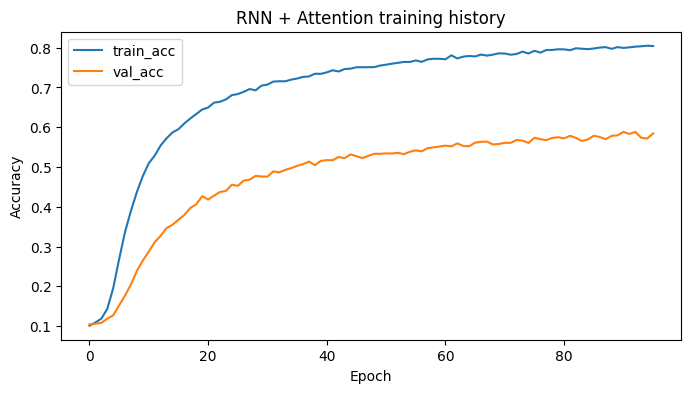

In [5]:
# Evaluación y predicción de siguiente palabra
from sklearn.metrics import accuracy_score

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {acc:.3f}')

def predict_next_word(context_words, top_n=5):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < 5:
        return []
    context_ids = np.array([context_ids[:5]], dtype=np.int32)
    probs = model.predict(context_ids, verbose=0)[0]
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(loader.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['bank', 'of', 'england', 'is', 'located'],
    ['queen', 'of', 'england', 'lives', 'in']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('RNN + Attention training history')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

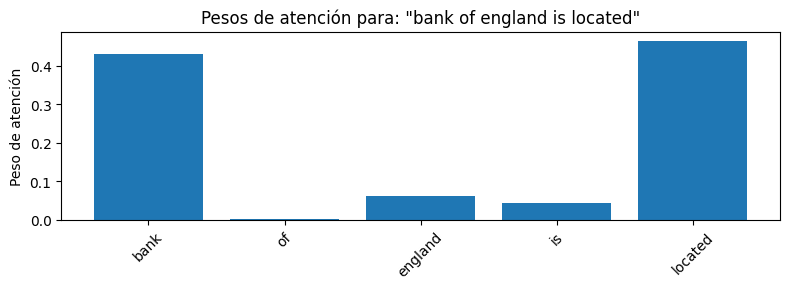

Interpretación: El modelo presta más atención a las palabras con mayor peso.
Idealmente, 'england' y 'bank' deberían tener pesos altos para predecir la siguiente palabra.


In [6]:
# Visualización de la matriz de atención
# Para ver qué palabras del contexto pesan más en la predicción

def get_attention_weights(context_words):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < 5:
        return None
    context_ids = np.array([context_ids[:5]], dtype=np.int32)
    
    # Extraemos los pesos de atención del modelo
    # Ejecutamos hasta la capa de atención
    x = model.embedding(context_ids)
    h = tf.zeros((1, model.hidden_dim))
    hidden_states = []
    for xt in tf.unstack(x, axis=1):
        h = tf.tanh(model.Wx(xt) + model.Wh(h) + model.b)
        hidden_states.append(h)
    H = tf.stack(hidden_states, axis=1)
    final_h = h
    
    H_proj = model.W_att(H)
    final_h_proj = tf.expand_dims(model.W_att(final_h), 1)
    scores = tf.reduce_sum(model.v_att * tf.tanh(H_proj + final_h_proj), axis=-1)
    att_weights = tf.nn.softmax(scores, axis=-1)
    return att_weights.numpy()[0]

sample_context = ['bank', 'of', 'england', 'is', 'located']
weights = get_attention_weights(sample_context)

if weights is not None:
    plt.figure(figsize=(8, 3))
    plt.bar(range(len(sample_context)), weights)
    plt.xticks(range(len(sample_context)), sample_context, rotation=45)
    plt.title('Pesos de atención para: "bank of england is located"')
    plt.ylabel('Peso de atención')
    plt.tight_layout()
    plt.show()
    
    print("Interpretación: El modelo presta más atención a las palabras con mayor peso.")
    print("Idealmente, 'england' y 'bank' deberían tener pesos altos para predecir la siguiente palabra.")

## Comparación de resultados

| Notebook | Modelo | Window | step | Test Accuracy |
|----------|--------|:-----:|:----:|:------------:|
| 18 | RNN vanilla | 5 | 1 | 0.403 |
| 19 | RNN + gradient clipping | 64 | **5** (original) | 0.105 |
| 19 | RNN + gradient clipping | 64 | **1** (corregido) | **0.420** |
| **20** | **RNN + Attention** | **5** | **1** | **0.575** |

**Evolución:**
- 18: Línea base — 0.403
- 19: `step=5` original falló (0.105); corregido a `step=1` logra 0.420 (casi igual a 18)
- **20: Attention supera a ambos con 0.575** +17 puntos sobre 18

**Conclusión:** La atención (20) añade muy pocos parámetros extra pero permite que el modelo use toda la secuencia, superando tanto a RNN vanilla como a gradient clipping.